# Stock Trend Forecasting (F&O)

This project models a **daily implied-volatility-style surface** from `training_data.csv`: for each **Date** and option **Tenor** (2M … 40Y), values are given across **moneyness** columns (0.1 … 1.9). That structure matches how F&O desks summarize risk and pricing across strikes and expiries.

**Goal:** learn temporal patterns from history, validate on a recent time window, then **fill** `prediction_template.csv` for out-of-sample dates.

**Method:** panel regression with per-(Tenor, moneyness) **lags** and short **rolling means**, plus **calendar** features, fitted with scikit-learn **`HistGradientBoostingRegressor`**. Forecasting is **recursive** (each new day uses prior predictions as lags where needed).

*Educational use only — not investment advice.*

In [10]:
# Optional: install once in this environment
# %pip install pandas numpy scikit-learn matplotlib seaborn

In [11]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")

ROOT = Path(".")
TRAIN_CSV = ROOT / "training_data.csv"
TEMPLATE_CSV = ROOT / "prediction_template.csv"
OUT_CSV = ROOT / "predictions_filled.csv"

MONEYNESS_COLS = [
    "0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9",
    "1", "1.1", "1.2", "1.3", "1.4", "1.5", "1.6", "1.7", "1.8", "1.9",
]
MONEYNESS_FLOATS = [float(c) for c in MONEYNESS_COLS]


def snap_moneyness(v: float) -> float:
    v = float(v)
    return min(MONEYNESS_FLOATS, key=lambda x: abs(x - v))


def tenor_to_years(tenor: str) -> float:
    t = str(tenor).strip().upper()
    if t.endswith("M"):
        return int(t[:-1]) / 12.0
    if t.endswith("Y"):
        return float(t[:-1])
    raise ValueError(f"Unknown tenor: {tenor!r}")


def wide_to_long(df: pd.DataFrame) -> pd.DataFrame:
    long_df = df.melt(
        id_vars=["Date", "Tenor"],
        value_vars=MONEYNESS_COLS,
        var_name="moneyness",
        value_name="value",
    )
    long_df["moneyness"] = long_df["moneyness"].astype(float).map(snap_moneyness)
    long_df["tenor_years"] = long_df["Tenor"].map(tenor_to_years)
    long_df["Date"] = pd.to_datetime(long_df["Date"])
    return long_df.sort_values(["Date", "Tenor", "moneyness"]).reset_index(drop=True)


def add_group_features(long_df: pd.DataFrame) -> pd.DataFrame:
    long_df = long_df.sort_values(["Tenor", "moneyness", "Date"]).reset_index(drop=True)
    g = long_df.groupby(["Tenor", "moneyness"], sort=False)["value"]
    long_df["lag_1"] = g.shift(1)
    long_df["lag_5"] = g.shift(5)
    long_df["roll_mean_5"] = g.transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean()
    )
    return long_df


def add_calendar_features(long_df: pd.DataFrame) -> pd.DataFrame:
    d = long_df["Date"]
    long_df["dow"] = d.dt.dayofweek
    long_df["month"] = d.dt.month
    long_df["days_since_start"] = (d - d.min()).dt.days
    return long_df


FEATURE_COLS = [
    "tenor_years", "moneyness", "dow", "month", "days_since_start",
    "lag_1", "lag_5", "roll_mean_5",
]

In [12]:
def train_and_validate(long_train: pd.DataFrame, val_days: int = 80):
    df = add_group_features(long_train.copy())
    df = add_calendar_features(df)
    dates = np.sort(df["Date"].unique())
    cutoff = pd.Timestamp(dates[-val_days] if len(dates) > val_days else dates[len(dates) // 5])
    train_mask = df["Date"] < cutoff
    val_mask = df["Date"] >= cutoff
    tr = df.loc[train_mask & df["lag_1"].notna()]
    va = df.loc[val_mask & df["lag_1"].notna()]
    X_tr, y_tr = tr[FEATURE_COLS], tr["value"]
    X_va, y_va = va[FEATURE_COLS], va["value"]
    model = HistGradientBoostingRegressor(
        max_depth=10,
        learning_rate=0.06,
        max_iter=300,
        l2_regularization=1e-3,
        early_stopping=True,
        validation_fraction=0.08,
        random_state=42,
    )
    model.fit(X_tr, y_tr)
    pred = model.predict(X_va)
    metrics = {
        "val_mae": float(mean_absolute_error(y_va, pred)),
        "val_rmse": float(np.sqrt(mean_squared_error(y_va, pred))),
        "val_rows": int(len(va)),
        "cutoff_date": str(cutoff.date()),
    }
    return model, metrics


def fit_full_model(long_train: pd.DataFrame) -> HistGradientBoostingRegressor:
    df = add_group_features(long_train.copy())
    df = add_calendar_features(df)
    tr = df.loc[df["lag_1"].notna()]
    model = HistGradientBoostingRegressor(
        max_depth=10,
        learning_rate=0.06,
        max_iter=350,
        l2_regularization=1e-3,
        random_state=42,
    )
    model.fit(tr[FEATURE_COLS], tr["value"])
    return model


def predict_surface_recursive(
    model: HistGradientBoostingRegressor,
    history_long: pd.DataFrame,
    predict_dates: pd.DatetimeIndex,
    tenors: list,
) -> pd.DataFrame:
    series = {}
    for (tenor, m), grp in history_long.groupby(["Tenor", "moneyness"], sort=False):
        series[(tenor, float(m))] = grp.sort_values("Date")["value"].astype(float).tolist()

    start_day0 = pd.Timestamp(history_long["Date"].min())
    out = []
    for d in predict_dates:
        dts = pd.Timestamp(d)
        rows_feat = []
        meta = []
        for tenor in tenors:
            ty = tenor_to_years(tenor)
            for m in MONEYNESS_FLOATS:
                key = (tenor, m)
                vals = series[key]
                lag_1 = vals[-1]
                lag_5 = vals[-5] if len(vals) >= 5 else vals[0]
                roll_mean_5 = float(np.mean(vals[-5:]))
                rows_feat.append(
                    {
                        "tenor_years": ty,
                        "moneyness": m,
                        "dow": dts.dayofweek,
                        "month": dts.month,
                        "days_since_start": (dts - start_day0).days,
                        "lag_1": lag_1,
                        "lag_5": lag_5,
                        "roll_mean_5": roll_mean_5,
                    }
                )
                meta.append(key)
        X = pd.DataFrame(rows_feat)[FEATURE_COLS]
        preds = model.predict(X)
        for pred, key in zip(preds, meta):
            series[key].append(float(pred))
            tenor, m = key
            out.append({"Date": dts, "Tenor": tenor, "moneyness": m, "value": float(pred)})
    return pd.DataFrame(out)


def format_date_template(ts: pd.Timestamp) -> str:
    return f"{ts.month}/{ts.day}/{ts.year}"


def build_submission(train_wide: pd.DataFrame, template: pd.DataFrame, val_days: int = 80):
    long_train = wide_to_long(train_wide)
    _, metrics = train_and_validate(long_train, val_days=val_days)
    model = fit_full_model(long_train)
    predict_dates = pd.DatetimeIndex(np.sort(pd.to_datetime(template["Date"].unique())))
    ten_order = template.drop_duplicates("Tenor")["Tenor"].tolist()
    pred_long = predict_surface_recursive(model, long_train, predict_dates, ten_order)
    m_map = {float(c): c for c in MONEYNESS_COLS}
    pred_long["m_col"] = pred_long["moneyness"].map(lambda v: m_map[round(float(v), 10)])
    wide_pred = pred_long.pivot_table(
        index=["Date", "Tenor"], columns="m_col", values="value", aggfunc="first"
    ).reset_index()
    wide_pred.columns.name = None
    wide_pred["Date"] = wide_pred["Date"].apply(lambda x: format_date_template(pd.Timestamp(x)))
    keys = template[["Date", "Tenor"]].copy()
    filled = keys.merge(wide_pred, on=["Date", "Tenor"], how="left")
    return filled[["Date", "Tenor"] + MONEYNESS_COLS], metrics, model

## 1. Load data

In [13]:
df_train = pd.read_csv(TRAIN_CSV)
df_template = pd.read_csv(TEMPLATE_CSV)
print("Training:", df_train.shape, "| Template:", df_template.shape)
df_train.head()

Training: (13642, 21) | Template: (1140, 21)


,Date,Tenor,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9
0,1/5/2017,2M,0.468214,0.419251,0.376260,0.338158,0.304372,0.274823,0.250066,0.231535,...,0.220933,0.228418,0.240437,0.254316,0.268613,0.282659,0.296172,0.309045,0.321260,0.332831
1,1/5/2017,3M,0.458471,0.412710,0.372717,0.337489,0.306511,0.279714,0.257540,0.241007,...,0.229423,0.233839,0.242411,0.253100,0.264611,0.276244,0.287647,0.298654,0.309196,0.319254
2,1/5/2017,6M,0.410305,0.374189,0.343045,0.316070,0.292842,0.273231,0.257346,0.245440,...,0.234116,0.234078,0.236765,0.241295,0.246945,0.253200,0.259726,0.266312,0.272831,0.279207
3,1/5/2017,9M,0.385267,0.354580,0.328360,0.305878,0.286712,0.270643,0.257590,0.247529,...,0.236030,0.234085,0.234121,0.235658,0.238264,0.241586,0.245360,0.249397,0.253564,0.257773
4,1/5/2017,1Y,0.358986,0.333608,0.312126,0.293870,0.278408,0.265457,0.254819,0.246339,...,0.235185,0.232109,0.230384,0.229760,0.230003,0.230908,0.232303,0.234052,0.236049,0.238213


## 2. Exploratory analysis

In [14]:
print("Missing values (total):", int(df_train.isnull().sum().sum()))
print("Unique trading dates:", df_train["Date"].nunique())
print("Tenors:", df_train["Tenor"].nunique())

Missing values (total): 0
Unique trading dates: 718
Tenors: 19


In [15]:
num_cols = [c for c in df_train.columns if c not in ("Date", "Tenor")]
df_train[num_cols].describe().T.head(12)

,count,mean,std,min,25%,50%,75%,max
0.1,13642.0,0.331881,0.083411,0.205536,0.284578,0.316036,0.351950,0.687277
0.2,13642.0,0.302007,0.072003,0.189889,0.260605,0.288831,0.323987,0.630411
0.3,13642.0,0.276614,0.062428,0.172411,0.239663,0.265497,0.300552,0.578715
0.4,13642.0,0.254600,0.054320,0.156772,0.221827,0.245631,0.280610,0.531344
0.5,13642.0,0.235275,0.047522,0.143881,0.206527,0.228131,0.262412,0.487723
0.6,13642.0,0.218217,0.042011,0.133259,0.193467,0.211791,0.245555,0.447510
0.7,13642.0,0.203196,0.037857,0.124634,0.181453,0.197402,0.229335,0.410605
0.8,13642.0,0.190163,0.035125,0.117846,0.169807,0.183689,0.215078,0.377628
0.9,13642.0,0.179293,0.033674,0.112773,0.157350,0.172807,0.203704,0.349102
1,13642.0,0.171110,0.032751,0.109262,0.148284,0.165296,0.194748,0.325423


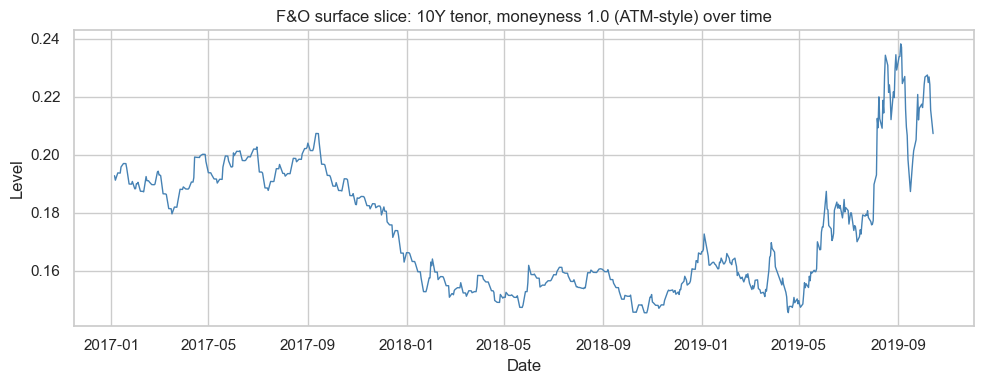

In [16]:
df_train["Date"] = pd.to_datetime(df_train["Date"])
long = wide_to_long(df_train)
sample = long[(long["Tenor"] == "10Y") & (long["moneyness"] == 1.0)].sort_values("Date")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sample["Date"], sample["value"], lw=1, color="steelblue")
ax.set_title("F&O surface slice: 10Y tenor, moneyness 1.0 (ATM-style) over time")
ax.set_ylabel("Level")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

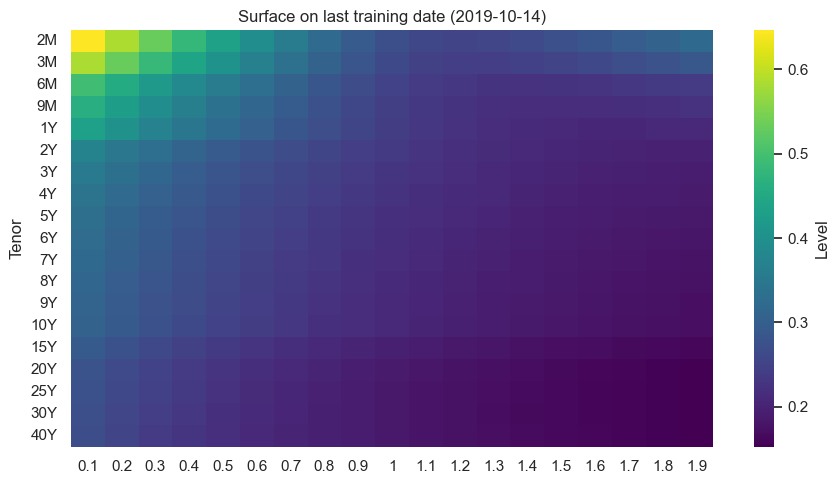

In [17]:
df_train["Date"] = pd.to_datetime(df_train["Date"])
last_day = df_train["Date"].max()
slice_day = df_train.loc[df_train["Date"] == last_day]
pivot = slice_day.set_index("Tenor")[MONEYNESS_COLS].astype(float)
tenor_order = df_train["Tenor"].unique().tolist()
pivot = pivot.reindex([t for t in tenor_order if t in pivot.index])
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, cmap="viridis", ax=ax, cbar_kws={"label": "Level"})
ax.set_title(f"Surface on last training date ({last_day.date()})")
plt.tight_layout()
plt.show()

## 3. Train, time-based validation, and forecast

The last `VAL_DAYS` dates in the training file are held out to report **MAE** and **RMSE**. The production model is refit on **all** training history, then used to fill the template **day by day** (recursive lags).

In [18]:
VAL_DAYS = 80
filled, metrics, model = build_submission(df_train, df_template, val_days=VAL_DAYS)
metrics

{'val_mae': 0.0054796485944518135,
 'val_rmse': 0.008243498835733725,
 'val_rows': 28880,
 'cutoff_date': '2019-06-25'}

In [19]:
filled.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV.resolve()} ({len(filled)} rows)")

Saved: D:\yash\Personal_data\Project\F-O-Prediction-Stock-market\predictions_filled.csv (1140 rows)


## 4. Sanity check and quick visualization

In [20]:
fp = filled[(filled["Date"] == filled["Date"].iloc[0]) & (filled["Tenor"] == "10Y")].iloc[0]
lt = df_train.sort_values("Date").query('Tenor == "10Y"').iloc[-1]
nc = [c for c in filled.columns if c not in ("Date", "Tenor")]
step = np.abs(fp[nc].astype(float).values - lt[nc].astype(float).values).mean()
print(f"Mean |change| moneyness-wise: last train 10Y vs first forecast day 10Y = {step:.6f}")

Mean |change| moneyness-wise: last train 10Y vs first forecast day 10Y = 0.006894


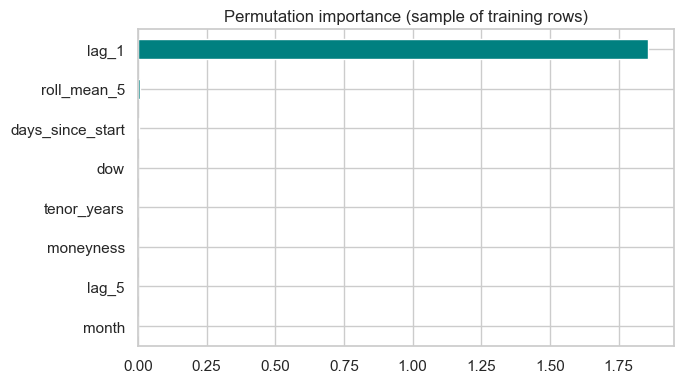

In [21]:
from sklearn.inspection import permutation_importance

_lt = wide_to_long(df_train)
_lt = add_group_features(_lt)
_lt = add_calendar_features(_lt)
_tr = _lt.loc[_lt["lag_1"].notna()]
_sample = _tr.sample(n=min(2500, len(_tr)), random_state=42)
perm = permutation_importance(
    model,
    _sample[FEATURE_COLS],
    _sample["value"],
    n_repeats=4,
    random_state=42,
    n_jobs=1,
)
imp = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind="barh", ax=ax, color="teal")
ax.set_title("Permutation importance (sample of training rows)")
plt.tight_layout()
plt.show()

## 5. Project summary

- **Inputs:** `training_data.csv` (historical surface), `prediction_template.csv` (dates/tenors to fill).
- **Output:** `predictions_filled.csv` aligned with the template.
- **Model:** gradient boosting on lagged surface levels and calendar features; validation metrics are printed above.

**Limitations:** no explicit no-arbitrage or options-pricing constraints; for research and learning. Extend with regime features, alternative models, or walk-forward backtests if you need stronger evidence of predictive power.